In [99]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='gemma3:4b',
    # base_url=os.getenv("OPENAI_API_BASE"),
    # api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.3,
    max_tokens=50
)

In [88]:
# 1. Define the state

from typing import TypedDict

class State(TypedDict):
    application: str
    experience_level: str
    skill_match: bool
    response: str


In [90]:
# 2. Define the nodes

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def categorize_experience(state: State) -> State:
    # We return the new name to update the state
    prompt = ChatPromptTemplate.from_template(
        "You are a helpful assistant that categorizes experience levels based on the application"
        "Categorize the experience level as 'Entry', 'Mid', or 'Senior'."
        "Application: {application}"
    )
    chain = prompt | llm | StrOutputParser()
    experience_level = chain.invoke({"application": state["application"]})
    return { "experience_level": experience_level }

def check_skill_match(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        "You are a helpful assistant that checks if the skills in the application are a match for a python developer."
        "Response should be 'Yes' or 'No'."
        "Application: {application}"
    )
    chain = prompt | llm | StrOutputParser()
    skill_match = chain.invoke({"application": state["application"]})
    return { "skill_match": skill_match }

def schedule_interview(state: State) -> State:
    return { "response": "Yes, we will schedule an interview for you." }

def reject_application(state: State) -> State:
    return { "response": "No, we will not schedule an interview for you." }

def escalate_application(state: State) -> State:
    return { "response": "We will escalate this application to the hiring manager." }

def route_application(state: State) -> State:
    if state["skill_match"] == "Yes":
        return "schedule"
    elif state["experience_level"] == "Senior":
        return "escalate"
    else:
        return "reject"

In [94]:
# 3. Create and build the graph
from langgraph.graph import StateGraph, END, START

workflow = StateGraph(State)

# Add nodes
workflow.add_node("categorize", categorize_experience)
workflow.add_node("assess", check_skill_match)
workflow.add_node("schedule", schedule_interview)
workflow.add_node("reject", reject_application)
workflow.add_node("escalate", escalate_application)

In [95]:
# Add edges
workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "assess")
workflow.add_conditional_edges(
    "assess", route_application, {"schedule": "schedule", "reject": "reject", "escalate": "escalate"}
)
# workflow.add_edge("assess", "schedule")
# workflow.add_edge("assess", "reject")
# workflow.add_edge("assess", "escalate")
workflow.add_edge("assess", END)
workflow.add_edge("schedule", END)
workflow.add_edge("reject", END)
workflow.add_edge("escalate", END)

app = workflow.compile()

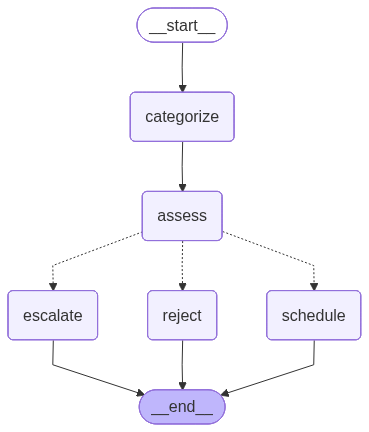

In [96]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [97]:
def run_application(application: str):
    state = {"application": application}
    results = app.invoke(state)
    return {
      "experience_level" : results["experience_level"],
      "skill_match" : results["skill_match"],
      "response" : results["response"]
    }

In [100]:
applications = [
    "I have 10 years of experience in Python and Django and I am looking for a new role as a Python Developer.",
    "I have 1 year of experience in Python and Django and I am looking for a new role as a Python Developer.",
    "I have 10 years of experience in JavaScript and React and I am looking for a new role as a JavaScript Developer.",
    "I have 1 year of experience in JavaScript and React and I am looking for a new role as a JavaScript Developer.",
]

for application in applications:
    results = run_application(application)
    print("\n\nComputed Results :")
    print(f"Application: {application}")
    print(f"Experience Level: {results['experience_level']}")
    print(f"Skill Match: {results['skill_match']}")
    print(f"Response: {results['response']}")



Computed Results :
Application: I have 10 years of experience in Python and Django and I am looking for a new role as a Python Developer.
Experience Level: Okay, based on your 10 years of experience in Python and Django, I would categorize your experience level as **Senior**. 

Here’s my reasoning:

*   **10 years is a significant amount of time** in software development, particularly with a focused technology stack like Python and Django.
*   At this level, you’d typically be expected to:
    *   Lead projects or contribute significantly to complex projects.
    *   Mentor junior developers.
    *   Have a deep understanding of best practices and design patterns.
    *   Be capable of making architectural decisions.

Let me know if you’d like me to elaborate on any aspect of this categorization!
Skill Match: Yes

Response: No, we will not schedule an interview for you.


Computed Results :
Application: I have 1 year of experience in Python and Django and I am looking for a new role 